In [36]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

## Data Preprocessing

To prepare the [UAV Drone Dataset](https://www.kaggle.com/datasets/dasmehdixtr/drone-dataset-uav) for PCA, we transform raw images into a standardized mathematical matrix $X$.

### 1. Extraction (YOLO Parsing)
Each image has a `.txt` file with normalized coordinates ($x_{center}, y_{center}, w, h$). We use this data to **crop** the drone, removing background noise like trees or sky. 

### 2. Standardization
For PCA to function, all input vectors must have the same dimensionality:
* **Grayscale:** Reduces data from 3 channels (RGB) to 1.
* **Resizing:** Every crop is scaled to a uniform $64 \times 64$ size.
* **Flattening:** The $2D$ image matrix is unrolled into a $1D$ vector of $4096$ pixels ($n = 4096$). 

### 3. Normalization
Pixel values are scaled to $[0, 1]$ to ensure the variance in PCA is driven by the drone's structural features rather than lighting conditions. 

**Result:** A data matrix $X$ where each row is a cleaned, standardized drone signature.

In [38]:
def read_image(img_path):
    """Read image using CV library"""
    return cv2.imread(img_path)

def read_yolo_file(txt_path):
    """Read text yolo file"""
    with open(txt_path, 'r', encoding='utf-8') as f:
        drones = []
        
        for line in f:
            data = line.strip().split()
            if not data or len(data) < 5: 
                continue
            drone = {}
            drone['class_id'] = int(data[0])
            drone['x_center_norm'] = float(data[1])
            drone['y_center_norm'] = float(data[2])
            drone['width_norm'] = float(data[3])
            drone['height_norm'] = float(data[4])
            drones.append(drone)
    return drones

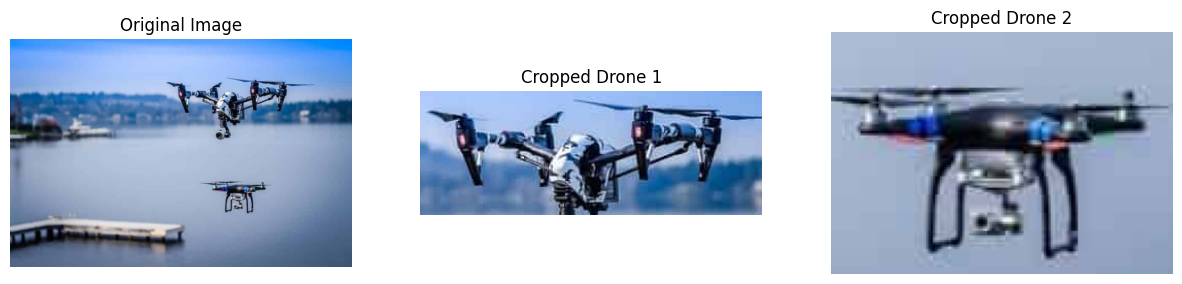

In [39]:
def crop_yolo_object(image, drones_yolo):
    """Croping the image using information from YOLO"""
    if image is None:
        return None
    
    if not drones_yolo:
        return None
    
    img_height, img_width = image.shape[:2]
    cropped_images = [] 
    
    for drone_yolo in drones_yolo:
        x_center = drone_yolo['x_center_norm'] * img_width
        y_center = drone_yolo['y_center_norm'] * img_height
        box_width = drone_yolo['width_norm'] * img_width
        box_height = drone_yolo['height_norm'] * img_height
        
        x1 = int(x_center - (box_width / 2))
        y1 = int(y_center - (box_height / 2))
        x2 = int(x_center + (box_width / 2))
        y2 = int(y_center + (box_height / 2))
        
        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_width, x2)
        y2 = min(img_height, y2)

        cropped_image = image[y1:y2, x1:x2]
        cropped_images.append(cropped_image)

    return cropped_images


def crop_drone(img_path, yolo_path):
    """Crop images to leave only drone"""
    img = read_image(img_path)
    drones_yolo = read_yolo_file(yolo_path)
    return crop_yolo_object(img, drones_yolo)
    
img_path = './archive/drone_dataset_yolo/dataset_txt/0010.jpg'
txt_path = './archive/drone_dataset_yolo/dataset_txt/0010.txt'

cropped_drones_list = crop_drone(img_path, txt_path) 
orig_img = read_image(img_path)

if cropped_drones_list is not None and orig_img is not None:
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    total_images = 1 + len(cropped_drones_list)
    fig, axes = plt.subplots(1, total_images, figsize=(5 * total_images, 5))
    
    if total_images == 2:
        axes = [axes[0], axes[1]]
    
    axes[0].imshow(orig_img_rgb)
    axes[0].axis('off')
    axes[0].set_title("Original Image")
    
    for i, cropped_img in enumerate(cropped_drones_list):
        img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
        
        axes[i + 1].imshow(img_rgb)
        axes[i + 1].axis('off')
        axes[i + 1].set_title(f"Cropped Drone {i + 1}")
        
    plt.show()
else:
    print("Failed to process the image.")

### Load the Images

In [40]:
def flatten_image(image, target_size=(64, 64)):
    """Resize the image and flatten it"""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  
    image = cv2.resize(image, target_size)
    return image.flatten()

def create_drone_dataset(dataset_folder):
    """Create a dataset with all drones"""
    dataset_matrix = []
    
    for filename in os.listdir(dataset_folder):
        if filename.endswith(".jpg") or filename.endswith(".png"):
            img_path = os.path.join(dataset_folder, filename)
            txt_path = img_path.rsplit('.', 1)[0] + '.txt' 
            
            if os.path.exists(txt_path):
                img = read_image(img_path)
                drones_yolo = read_yolo_file(txt_path)
                cropped_drones_list = crop_yolo_object(img, drones_yolo)
                
                if cropped_drones_list is not None:
                    for drone_img in cropped_drones_list:
                        flat_drone = flatten_image(drone_img, target_size=(64, 64))
                        dataset_matrix.append(flat_drone)

    X = np.array(dataset_matrix)
    return X

folder_path = './archive/drone_dataset_yolo/dataset_txt'
X = create_drone_dataset(folder_path)

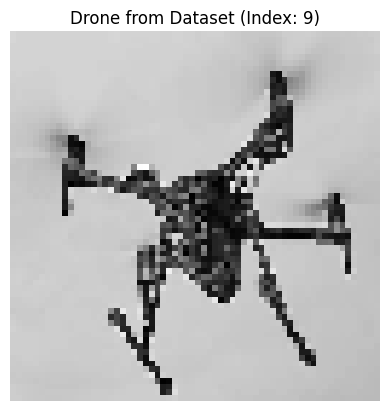

In [41]:
def show_drone_from_matrix(X, index=0, img_size=(64, 64)):
    """
    Displays a single image from the processed dataset matrix X.
    
    :param X: Dataset matrix (NumPy array)
    :param index: Index of the image to display (starting from 0)
    :param img_size: The target dimensions used during preprocessing (default 64x64)
    """
    # Check if the requested index exists in the matrix
    if index >= len(X):
        print(f"Error: The dataset contains only {len(X)} images. Index is out of bounds.")
        return

    # 1. Extract the specific row (vector) from the matrix
    flat_drone = X[index]

    # 2. Reshape the 1D vector (e.g., length 4096) 
    # back into a 2D image matrix (e.g., 64x64)
    drone_2d = flat_drone.reshape(img_size)

    # 3. Display the result using a grayscale colormap
    plt.imshow(drone_2d, cmap='gray')
    plt.title(f"Drone from Dataset (Index: {index})")
    plt.axis('off')
    plt.show()
show_drone_from_matrix(X, index=9)


Each image can be represented as a matrix of pixels. The RGB format involves a complex setup of three matrices representing the intensity of each color channel. To simplify calculations and improve efficiency, we convert the image to grayscale, which works effectively for the following algorithms.

For an image represented as an $N \times M$ matrix, we flatten it into an $NM \times 1$ vector to execute subsequent vector operations.

### Data Normalization

The next step for the PCA algorithm is data normalization. We define our data matrix $X$ as:

$$X = [x_1, x_2, x_3, \ldots, x_n] \tag{1}$$

where $x_i$ are the flattened image vectors from our dataset.

### Mean Vector

We then calculate the mean vector:

$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i \tag{2}$$

In [42]:
def calculate_mean_vector(X):
    mean_vector = np.mean(X, axis=0)
    return mean_vector

X_mean = calculate_mean_vector(X)
print(X)
print(X_mean)

[[219 221 221 ... 212 211 211]
 [208 208 208 ... 216 216 216]
 [233 233 234 ... 222 222 222]
 ...
 [ 40  42  48 ... 135 131 143]
 [159 158 158 ...  47  59  65]
 [172 169 172 ... 143 145 150]]
[180.38156124 180.7039031  181.3640646  ... 178.54912517 178.75235532
 179.3526245 ]


### Centralized Data

The centralized data of the set is then represented as:

$$\bar{x}_i = x_i - \mu \tag{3}$$

In [43]:
def centralize_data(X, mean_vector):
    X_centered = X - mean_vector
    return X_centered

X_centered = centralize_data(X, X_mean)
print(X_centered)

[[  38.61843876   40.2960969    39.6359354  ...   33.45087483
    32.24764468   31.6473755 ]
 [  27.61843876   27.2960969    26.6359354  ...   37.45087483
    37.24764468   36.6473755 ]
 [  52.61843876   52.2960969    52.6359354  ...   43.45087483
    43.24764468   42.6473755 ]
 ...
 [-140.38156124 -138.7039031  -133.3640646  ...  -43.54912517
   -47.75235532  -36.3526245 ]
 [ -21.38156124  -22.7039031   -23.3640646  ... -131.54912517
  -119.75235532 -114.3526245 ]
 [  -8.38156124  -11.7039031    -9.3640646  ...  -35.54912517
   -33.75235532  -29.3526245 ]]


### Covariance Matrix

The following step involves calculating the covariance matrix using the formula:

$$C = \frac{1}{n} \bar{X} \bar{X}^T \tag{4}$$

To optimize calculation for high-resolution images, we use a mathematical trick by defining a smaller matrix $C'$:

$$C' = \bar{X}^T \bar{X} \tag{5}$$

This allows us to process datasets where the number of images is much smaller than the number of pixels.

In [44]:
def calculate_covariance_matrix(X):
    # Center the data
    X_centered = centralize_data(X, calculate_mean_vector(X))
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)

    return covariance_matrix

print(calculate_covariance_matrix(X))

[[5417.96542409 5268.89689357 5116.70678476 ... 3655.77821281
  3685.20835996 3681.58388007]
 [5268.89689357 5374.78499486 5194.22436931 ... 3603.86573406
  3626.46534434 3635.60145103]
 [5116.70678476 5194.22436931 5281.61080205 ... 3592.58041972
  3593.82422611 3589.77658596]
 ...
 [3655.77821281 3603.86573406 3592.58041972 ... 5325.58378038
  5204.21958119 5010.92340634]
 [3685.20835996 3626.46534434 3593.82422611 ... 5204.21958119
  5324.75344563 5126.39176149]
 [3681.58388007 3635.60145103 3589.77658596 ... 5010.92340634
  5126.39176149 5232.11530287]]


## Eigenvectors and Eigenvalues

To proceed, we must utilize Eigenvectors and Eigenvalues. By definition, the transformation of an eigenvector $v$ by a matrix $A$ is:

$$Av = \lambda v \tag{6}$$

where $\lambda$ represents the eigenvalue.

Assuming $C' = \bar{X}^T \bar{X}$ is our $A$:

$$(\bar{X}^T \bar{X}) v = \lambda v \tag{7}$$

Left-multiplying by $\bar{X}$:

$$(\bar{X} \bar{X}^T)(\bar{X} v) = \lambda (\bar{X} v) \tag{8}$$

This proves that $(\bar{X} v)$ is the eigenvector of the large covariance matrix $C$.

In [45]:
def qr_eigen(A, max_iterations=20, tol=1e-5):
    A_k = np.copy(A).astype(float)
    n = A.shape[0]
    qq = np.eye(n) 

    for i in range(max_iterations):
        q, r = np.linalg.qr(A_k)
        A_k = r @ q
        qq = qq @ q

        # Early Stopping
        off_diagonal = np.linalg.norm(np.tril(A_k, -1))
        if off_diagonal < tol:
            break
            
    return np.diag(A_k), qq


def fast_pca_algorithm(X):
    X_mean = calculate_mean_vector(X)
    X_centered = centralize_data(X, X_mean)
    
    # Gram matrix trick
    K = (X_centered @ X_centered.T) / (X.shape[0] - 1)
    
    evals, v_small = qr_eigen(K)
    
    # sorting the results (important for PCA)
    idx = evals.argsort()[::-1]
    evals = evals[idx]
    v_small = v_small[:, idx]
    
    # Turning small eigenvectors into eigenvectors of the large covariance matrix
    # V_large = X^T * V_small
    eigenvectors_large = X_centered.T @ v_small
    
    # Vectors Normalization: normalizing the eigenvectors to unit length
    for i in range(eigenvectors_large.shape[1]):
        norm = np.linalg.norm(eigenvectors_large[:, i])
        if norm > 1e-15:
            eigenvectors_large[:, i] /= norm
            
    return evals, eigenvectors_large


evals, evecs = fast_pca_algorithm(X)

print(f"Eigenvalues quantity: {len(evals)}")
print(f"Shape of eigenvectors matrix: {evecs.shape}")
print("First 3 eigenvalues:", evals[:3])

print(fast_pca_algorithm(X))

Eigenvalues quantity: 1486
Shape of eigenvectors matrix: (4096, 1486)
First 3 eigenvalues: [8857398.48898217 1581405.44327752  647416.2100681 ]
(array([8.85739849e+06, 1.58140544e+06, 6.47416210e+05, ...,
       1.21179962e+00, 8.25238736e-01, 2.48788853e-11], shape=(1486,)), array([[ 0.02022459, -0.01572823,  0.01701357, ..., -0.00456982,
         0.00371652,  0.00751221],
       [ 0.01996169, -0.01590833,  0.0173193 , ...,  0.01706265,
         0.00368691,  0.01752849],
       [ 0.01997543, -0.01550813,  0.01686687, ...,  0.00978159,
         0.01292773,  0.02131513],
       ...,
       [ 0.01965415, -0.01441002, -0.00804448, ...,  0.00653673,
        -0.0087181 ,  0.00036645],
       [ 0.01970574, -0.01470974, -0.00841173, ...,  0.00085225,
         0.00274705,  0.00329804],
       [ 0.01952796, -0.01514972, -0.00774324, ..., -0.00239653,
        -0.0065997 ,  0.01197068]], shape=(4096, 1486)))


## Power Method and Projection

We use the power method to find the dominant eigenvector:

$$x_{k+1} = \frac{A x_k}{\| A x_k \|} \tag{9}$$

This iterates until convergence. We then build matrix $Y$ (the "eigendrone" space) and project our data:

$$Z = Y^T \bar{X} \tag{10}$$

For a test image $x_{\text{test}}$, we center and project it:

$$Z_{\text{test}} = Y^T (x_{\text{test}} - \mu) \tag{11}$$

Finally, we calculate the Euclidean distance between projections. If the distance is below an experimental threshold, the object is classified as a drone.

In [46]:
import numpy as np

def power_method(C, epsilon=1e-6, max_iter=1000):
    n = C.shape[0]
    evec = np.random.rand(n) # getting random vector
    evec = evec / np.linalg.norm(evec) # normalizing

    for _ in range(max_iter):
        new_evec = C @ evec
        b_new_norm = np.linalg.norm(new_evec) 

        if b_new_norm == 0:
            return evec, 0

        new_evec = new_evec / b_new_norm

        # ВИПРАВЛЕННЯ 1: Захист від "перевертання" знаку вектора
        # Використовуємо скалярний добуток. Якщо вектори паралельні (навіть якщо
        # дивляться в різні боки), модуль їх скалярного добутку буде 1.0
        if 1.0 - np.abs(np.dot(new_evec, evec)) < epsilon:
            break

        evec = new_evec

    # Рахуємо власне значення (відношення Релея)
    eigenvalue = np.dot(evec.T, np.dot(C, evec))
    return evec, eigenvalue


def power_method_pca(covariance_matrix, variance_threshold=0.95):
    C = covariance_matrix.copy()
    
    # След матриці (Trace) дорівнює сумі всіх власних значень
    total_variance = np.trace(C) 

    eigenvectors = []
    eigenvalues = []
    explained_variance = 0.0

    while explained_variance < variance_threshold:
        v, e = power_method(C)

        # Якщо власне значення занадто мале (шум) - зупиняємось
        if e <= 1e-10: 
            break

        # ВИПРАВЛЕННЯ 2: Примусова ортогоналізація (Метод Грама-Шмідта)
        # Очищаємо новий вектор від будь-яких залишків попередніх векторів,
        # які могли з'явитися через похибку чисел з плаваючою комою.
        for prev_v in eigenvectors:
            v = v - np.dot(v, prev_v) * prev_v
        
        # Нормалізуємо ще раз після очищення
        v_norm = np.linalg.norm(v)
        if v_norm > 0:
            v = v / v_norm

        eigenvectors.append(v)
        eigenvalues.append(e)

        explained_variance = sum(eigenvalues) / total_variance

        # Дефляція: видаляємо проекцію цього вектора з матриці
        C = C - e * np.outer(v, v) 

    # Перетворюємо список векторів у матрицю.
    # Транспонуємо (.T), щоб власні вектори були СТОВПЦЯМИ, як це заведено в математиці
    return np.array(eigenvectors).T, np.array(eigenvalues)
# 1. Спочатку центруємо наші дані (віднімаємо середнього дрона)
mean_vector = np.mean(X, axis=0)
X_centered = X - mean_vector

# 2. Обчислюємо КОВАРІАЦІЙНУ МАТРИЦЮ (C)
# Її розмір буде (4096, 4096)
N = X_centered.shape[0]
C = (X_centered.T @ X_centered) / (N - 1)

# 3. ТІЛЬКИ ТЕПЕР передаємо матрицю C у наш алгоритм
# ПРАВИЛЬНИЙ ПОРЯДОК: спочатку evecs_1 (вектори), потім evals_1 (значення)
evecs_1, evals_1 = power_method_pca(C, variance_threshold=0.95)

print(f"Кількість власних значень: {len(evals_1)}")
print(f"Розмірність матриці векторів: {evecs_1.shape}") # Має бути (4096, 220)

Кількість власних значень: 215
Розмірність матриці векторів: (4096, 215)


In [47]:
print(evals_1[:3])

[8857384.86371874 1581480.86454054  647420.60040731]


### Testing

In [48]:
def z_test(X_test, mean_vector, eigenvectors):
    """
    Проектує нові зображення (X_test) у простір PCA.
    X_test може бути як однією картинкою (1D вектор), так і матрицею кількох картинок.
    """
    # Віднімаємо середнього дрона
    X_centered = X_test - mean_vector
    
    # Проектуємо дані (стискаємо)
    projections = np.dot(X_centered, eigenvectors)
    return projections

In [49]:
def calculate_euclidean_distance(projections, threshold):
    """
    Рахує відстань від спроектованих картинок до 'ідеального середнього дрона' (нуля в PCA).
    """
    # Якщо передали одну картинку (1D вектор), робимо її 2D матрицею з 1 рядком
    if projections.ndim == 1:
        projections = projections.reshape(1, -1)
        
    # Рахуємо Евклідову відстань для кожного рядка
    distances = np.linalg.norm(projections, axis=1)

    # Повертаємо і самі відстані, і рішення (True/False)
    is_drone = distances < threshold
    
    return distances, is_drone

In [50]:
# 1. Проектуємо весь наш тренувальний датасет (матрицю X) у простір PCA
Z_train = z_test(X, mean_vector, evecs_1)

# 2. Рахуємо відстані для всіх тренувальних дронів 
# (поріг тут ставимо нескінченність, бо нам потрібні лише цифри відстаней)
train_distances, _ = calculate_euclidean_distance(Z_train, threshold=float('inf'))

# 3. Аналізуємо відстані справжніх дронів
mean_dist = np.mean(train_distances)
max_dist = np.max(train_distances)

print(f"Середня відстань для справжніх дронів: {mean_dist:.2f}")
print(f"Максимальна відстань для справжніх дронів: {max_dist:.2f}")

# Встановлюємо поріг трохи більшим за середнє (або беремо максимум)
MY_THRESHOLD = mean_dist + np.std(train_distances)
print(f"Наш обраний поріг для тестування: {MY_THRESHOLD:.2f}")

Середня відстань для справжніх дронів: 4311.00
Максимальна відстань для справжніх дронів: 9513.17
Наш обраний поріг для тестування: 5598.76


In [51]:
# Припустимо, у тебе є якась нова картинка test_image (numpy array)
# 1. Робимо їй такий самий препроцесінг, як і тренувальним даним
# (переводимо в ч/б, робимо resize до 64x64, і flatten)
test_image1 = read_image('./example-test.jpg')
test_flat1 = flatten_image(test_image1, target_size=(64, 64))
test_image = read_image('./image_3.png')
test_flat = flatten_image(test_image, target_size=(64, 64))

# 2. Отримуємо проекцію за допомогою твоєї функції
test_projection = z_test(test_flat, mean_vector, evecs_1)

# 3. Перевіряємо, чи це дрон
distances, is_drone_array = calculate_euclidean_distance(test_projection, MY_THRESHOLD)

# Оскільки ми передали одну картинку, беремо 0-й елемент
dist = distances[0]
is_drone = is_drone_array[0]

if is_drone:
    print(f"✅ Це ДРОН! (Відстань: {dist:.2f} < Поріг: {MY_THRESHOLD:.2f})")
else:
    print(f"❌ Це НЕ дрон. (Відстань: {dist:.2f} > Поріг: {MY_THRESHOLD:.2f})")

✅ Це ДРОН! (Відстань: 3865.55 < Поріг: 5598.76)


In [54]:
def check_is_drone_no_background(test_flat, mean_vector, eigenvectors, drop_first_k=5):
    # 1. Центруємо
    centered_img = test_flat - mean_vector
    
    # 2. ВІДКИДАЄМО перші K векторів (які малюють фон та освітлення)
    # Беремо всі рядки, але стовпці починаємо з drop_first_k
    evecs_details = eigenvectors[:, drop_first_k:]
    
    # 3. Проектуємо та реконструюємо ТІЛЬКИ на векторах "деталей"
    weights = np.dot(centered_img, evecs_details)
    reconstructed_img = np.dot(weights, evecs_details.T)
    
    # 4. Рахуємо відносну помилку
    abs_error = np.linalg.norm(centered_img - reconstructed_img)
    img_complexity = np.linalg.norm(centered_img)
    
    if img_complexity == 0:
        return 0.0
        
    relative_error = abs_error / img_complexity
    
    return relative_error

error_sky = check_is_drone_no_background(test_flat, mean_vector, evecs_1)
error_real_drone = check_is_drone_no_background(test_flat1, mean_vector, evecs_1)

# Використовуємо твою функцію проекції
proj_sky = z_test(test_flat, mean_vector, evecs_1)
proj_drone = z_test(test_flat1, mean_vector, evecs_1)

# Рахуємо відстань до "Середнього дрона" (нуля в PCA)
dist_sky = np.linalg.norm(proj_sky)
dist_drone = np.linalg.norm(proj_drone)

print(f"ТВІЙ ПІДХІД - Відстань неба: {dist_sky}")
print(f"ТВІЙ ПІДХІД - Відстань дрона: {dist_drone}")

print(f"Помилка неба: {error_sky}")
print(f"Помилка дрона: {error_real_drone}")

ТВІЙ ПІДХІД - Відстань неба: 3865.5535221065934
ТВІЙ ПІДХІД - Відстань дрона: 3444.305139472705
Помилка неба: 0.682350773071994
Помилка дрона: 0.7686776007121734


Шукаю дрона...
✅ Дрона знайдено! Відстань: 1959.41 (Поріг: 2000)


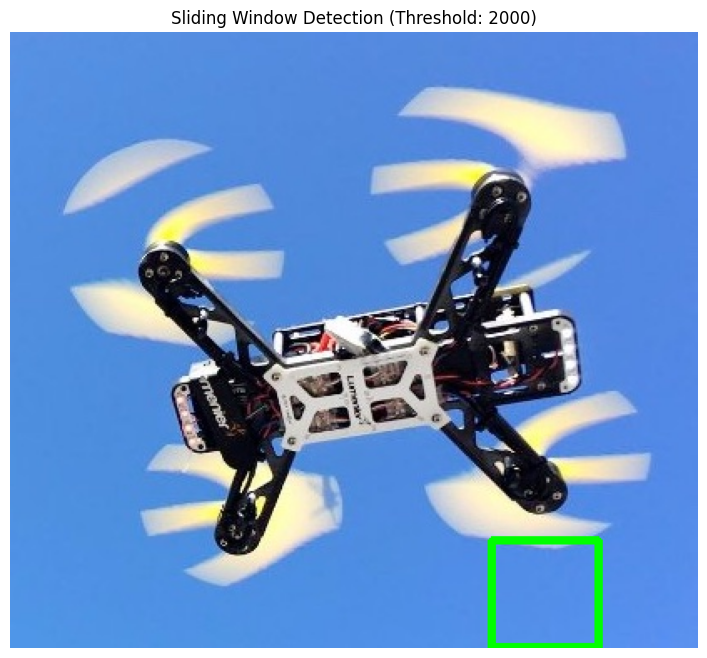

In [69]:
import cv2
import matplotlib.pyplot as plt

def detect_drone_sliding_window(large_image_path, mean_vector, eigenvectors, threshold=3600, window_size=(64, 64), step_size=16):
    # 1. Завантажуємо велику картинку
    img = cv2.imread(large_image_path)
    if img is None:
        print("Помилка: не знайдено картинку!")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Для красивого виводу
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # Для математики
    
    best_dist = float('inf')
    best_box = None
    
    print("Шукаю дрона...")
    
    # 2. "Їдемо" вікном по висоті та ширині
    for y in range(0, img_gray.shape[0] - window_size[1], step_size):
        for x in range(0, img_gray.shape[1] - window_size[0], step_size):
            
            # Вирізаємо поточне вікно
            window = img_gray[y:y + window_size[1], x:x + window_size[0]]
            
            # Робимо flatten (і нормалізацію, якщо ти ділив на 255 під час навчання)
            # Якщо ти не ділив на 255.0 в датасеті, то прибери це ділення тут!
            window_flat = window.flatten() # / 255.0 
            
            # 3. ВИКОРИСТОВУЄМО ТВОЇ ФУНКЦІЇ:
            test_projection = z_test(window_flat, mean_vector, eigenvectors)
            
            # Якщо згадаєш, test_projection може бути 1D, робимо reshape
            if test_projection.ndim == 1:
                test_projection = test_projection.reshape(1, -1)
                
            dist = np.linalg.norm(test_projection, axis=1)[0]
            
            # 4. Шукаємо найменшу відстань, яка менша за поріг
            if dist < threshold and dist < best_dist:
                best_dist = dist
                best_box = (x, y, window_size[0], window_size[1])
                
    # 5. Малюємо результат
    result_img = img_rgb.copy()
    if best_box is not None:
        x, y, w, h = best_box
        # Малюємо зелену рамку
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
        print(f"✅ Дрона знайдено! Відстань: {best_dist:.2f} (Поріг: {threshold})")
    else:
        print(f"❌ На картинці дронів не знайдено (Всі відстані > {threshold}).")
        
    plt.figure(figsize=(10, 8))
    plt.imshow(result_img)
    plt.axis('off')
    plt.title(f"Sliding Window Detection (Threshold: {threshold})")
    plt.show()

# --- Як запустити ---
# Знайди якусь велику фотографію дрона з датасету (не txt, а jpg) і протестуй!
test_large_img_path = './archive/drone_dataset_yolo/dataset_txt/0015.jpg'
detect_drone_sliding_window(test_large_img_path, mean_vector, evecs_1, threshold=2000)